# Lumen — Natural Scene Classification with CNN

A Convolutional Neural Network built from scratch to classify natural scene images into six categories (buildings, forest, glacier, mountain, sea, street), achieving 90.10% test accuracy.


In [ ]:
# fix the random seed for reproducibility across NumPy and TensorFlow
SEED = 42
import numpy as np
import tensorflow as tf
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
# mount Google Drive so all outputs (checkpoints, history, etc.) are saved persistently
from google.colab import drive
drive.mount('/content/drive')

import os
# create a dedicated folder in Drive to store the saved files
SAVE_DIR = '/content/drive/MyDrive/CS1465_Exam'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive


In [3]:
# install kagglehub its used to download datasets directly from Kaggle
!pip install kagglehub --quiet
import kagglehub

# download the intel image classification dataset from Kaggle
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

# store the dataset root path
DATA_DIR = path

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [4]:
import os

# recursively search for a folder with a given name inside 'base'
def find_dir(base, target_name):
    for root, dirs, files in os.walk(base):
        if os.path.basename(root) == target_name:
            return root
    return None

# locate the training and testing folders inside the downloaded dataset
TRAIN_DIR = find_dir(DATA_DIR, "seg_train")
TEST_DIR  = find_dir(DATA_DIR, "seg_test")

# handle the dataset's nested folder structure (seg_train/seg_train, seg_test/seg_test)
if os.path.isdir(os.path.join(TRAIN_DIR, "seg_train")):
    TRAIN_DIR = os.path.join(TRAIN_DIR, "seg_train")
if os.path.isdir(os.path.join(TEST_DIR, "seg_test")):
    TEST_DIR = os.path.join(TEST_DIR, "seg_test")

#print the resolved paths and the class folders found in each to verify everything loaded correctly
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("Train classes:", sorted(os.listdir(TRAIN_DIR)))
print("Test classes:", sorted(os.listdir(TEST_DIR)))

TRAIN_DIR: /kaggle/input/intel-image-classification/seg_train/seg_train
TEST_DIR: /kaggle/input/intel-image-classification/seg_test/seg_test
Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Test classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128
BATCH_SIZE = 32

# training data: normalize + augmentation to reduce overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,              # scale pixels to 0-1
    validation_split=0.15,       # 15% for validation
    rotation_range=25,           # random rotation
    width_shift_range=0.15,      # random horizontal shift
    height_shift_range=0.15,     # random vertical shift
    zoom_range=0.2,              # random zoom
    shear_range=0.1,             # slight shear
    horizontal_flip=True,        # flip images randomly
    brightness_range=[0.8, 1.2], # random brightness change
    fill_mode="nearest"          # fill empty pixels after shift/rotation
)

# validation data: only rescale, no augmentation
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.15)

# test data: only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# load training images
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="training", shuffle=True, seed=SEED
)

# load validation images
val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", subset="validation", shuffle=False, seed=SEED
)

# load test images (no shuffle so labels stay aligned with predictions)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)
print("Image type: RGB, normalized 0-1, one-hot encoded via categorical class_mode")

Found 11932 images belonging to 6 classes.
Found 2102 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Image type: RGB, normalized 0-1, one-hot encoded via categorical class_mode


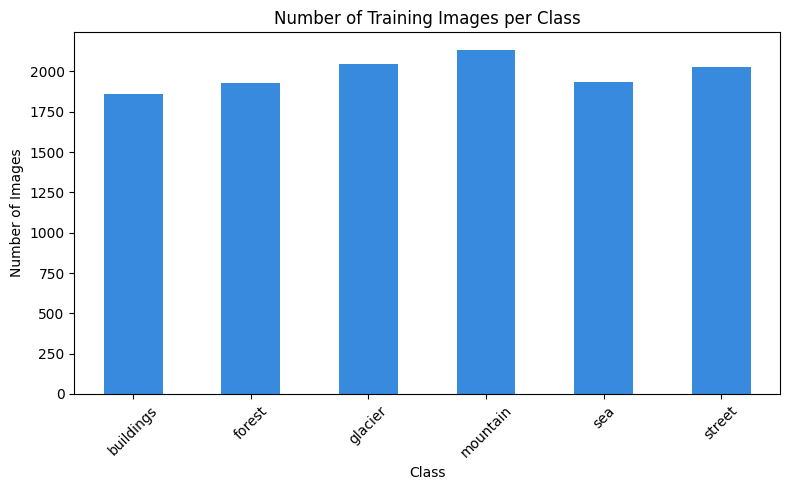

buildings    1863
forest       1931
glacier      2044
mountain     2136
sea          1933
street       2025
Name: count, dtype: int64

Total training images: 11932
Total validation images: 2102
Total test images: 3000


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# count how many training images are in each class
class_counts_train = pd.Series(train_gen.classes).value_counts().sort_index()
class_counts_train.index = class_names

# bar chart showing number of images per class
plt.figure(figsize=(8, 5))
class_counts_train.plot(kind='bar', color='#378ADD')
plt.title('Number of Training Images per Class')
plt.xlabel('Class'); plt.ylabel('Number of Images')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(class_counts_train)
print(f"\nTotal training images: {train_gen.samples}")
print(f"Total validation images: {val_gen.samples}")
print(f"Total test images: {test_gen.samples}")

In [7]:
from tensorflow.keras import layers, models, optimizers, callbacks

# builds the CNN model with adjustable dropout rate and learning rate
def build_model(dropout_rate=0.4, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),  # 128x128 RGB input

        # block 1: 32 filters
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # block 2: 64 filters
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # block 3: 128 filters
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        # block 4: 256 filters
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),  # replaces flatten and fewer params

        # dense classification head
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),  # regularization to reduce overfitting

        layers.Dense(NUM_CLASSES, activation="softmax")  # 6-class output
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=["accuracy"]
    )
    return model

# build and show the baseline model
model = build_model(dropout_rate=0.4, lr=1e-3)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,02

 Total params: 653,350 (2.49 MB)

 Trainable params: 651,430 (2.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [8]:
EPOCHS = 45

# stop training if val_loss doesn't improve for 8 epochs and keep best weights
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

# reduce learning rate when val_loss plateaus
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# train baseline model (Experiment 1: dropout=0.4, lr=1e-3)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# evaluate on test set
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nExperiment 1 Test Accuracy: {test_acc:.4f}")

Epoch 1/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 178s 429ms/step - accuracy: 0.5480 - loss: 1.4053 - val_accuracy: 0.2450 - val_loss: 2.5727 - learning_rate: 0.0010
Epoch 2/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 86s 230ms/step - accuracy: 0.6804 - loss: 1.1036 - val_accuracy: 0.6575 - val_loss: 1.1580 - learning_rate: 0.0010
Epoch 3/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 215ms/step - accuracy: 0.7347 - loss: 0.9898 - val_accuracy: 0.7122 - val_loss: 0.9874 - learning_rate: 0.0010
Epoch 4/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 81s 217ms/step - accuracy: 0.7762 - loss: 0.9014 - val_accuracy: 0.7369 - val_loss: 1.0210 - learning_rate: 0.0010
Epoch 5/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.7947 - loss: 0.8687 - val_accuracy: 0.7464 - val_loss: 0.9486 - learning_rate: 0.0010
Epoch 6/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.7995 - loss: 0.8531 - val_accuracy: 0.7992 - val_loss: 0.8763 - learning_rate: 0.0010
Epoch 7/45
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 216ms/step - accuracy: 0.

In [ ]:
# separate EarlyStopping and ReduceLROnPlateau callbacks for Experiment 2
early_stop_exp2 = callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)
reduce_lr_exp2 = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# clear the Keras session to fully reset the graph before building a new model
# to avoids any leftover state/weights from the Experiment 1 model
tf.keras.backend.clear_session()

# build a fresh model for Experiment 2 with different hyperparameters:
# higher dropout (0.5 vs 0.4) and lower learning rate (5e-4 vs 1e-3)
model_exp2 = build_model(dropout_rate=0.5, lr=5e-4)

# train Experiment 2 for up to 30 epochs
history_exp2 = model_exp2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop_exp2, reduce_lr_exp2],
    verbose=1
)

# fresh test generator for Experiment 2 evaluation 
test_gen_exp2 = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

# evaluate Experiment 2 on the test set
test_loss_exp2, test_acc_exp2 = model_exp2.evaluate(test_gen_exp2, verbose=1)

# compare both experiments' test accuracy
print(f"Experiment 1 (dropout=0.4, lr=1e-3, epochs=45): Test Accuracy = {test_acc:.4f}")
print(f"Experiment 2 (dropout=0.5, lr=5e-4, epochs=30): Test Accuracy = {test_acc_exp2:.4f}")

# select whichever model achieved the higher test accuracy
# as the "best" model used for the evaluation section 
best_model, best_history, best_acc = (
    (model, history, test_acc) if test_acc >= test_acc_exp2
    else (model_exp2, history_exp2, test_acc_exp2)
)
print(f"\nBest model test accuracy: {best_acc:.4f}")

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 99s 237ms/step - accuracy: 0.5260 - loss: 1.5381 - val_accuracy: 0.1974 - val_loss: 2.9074 - learning_rate: 5.0000e-04
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 213ms/step - accuracy: 0.6540 - loss: 1.1841 - val_accuracy: 0.6284 - val_loss: 1.2719 - learning_rate: 5.0000e-04
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.7140 - loss: 1.0526 - val_accuracy: 0.7369 - val_loss: 0.9917 - learning_rate: 5.0000e-04
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - accuracy: 0.7495 - loss: 0.9775 - val_accuracy: 0.7169 - val_loss: 1.0691 - learning_rate: 5.0000e-04
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 215ms/step - accuracy: 0.7799 - loss: 0.9116 - val_accuracy: 0.7864 - val_loss: 0.8966 - learning_rate: 5.0000e-04
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 81s 216ms/step - accuracy: 0.7998 - loss: 0.8717 - val_accuracy: 0.7027 - val_loss: 1.0815 - learning_rate: 5.0000e-04
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 21

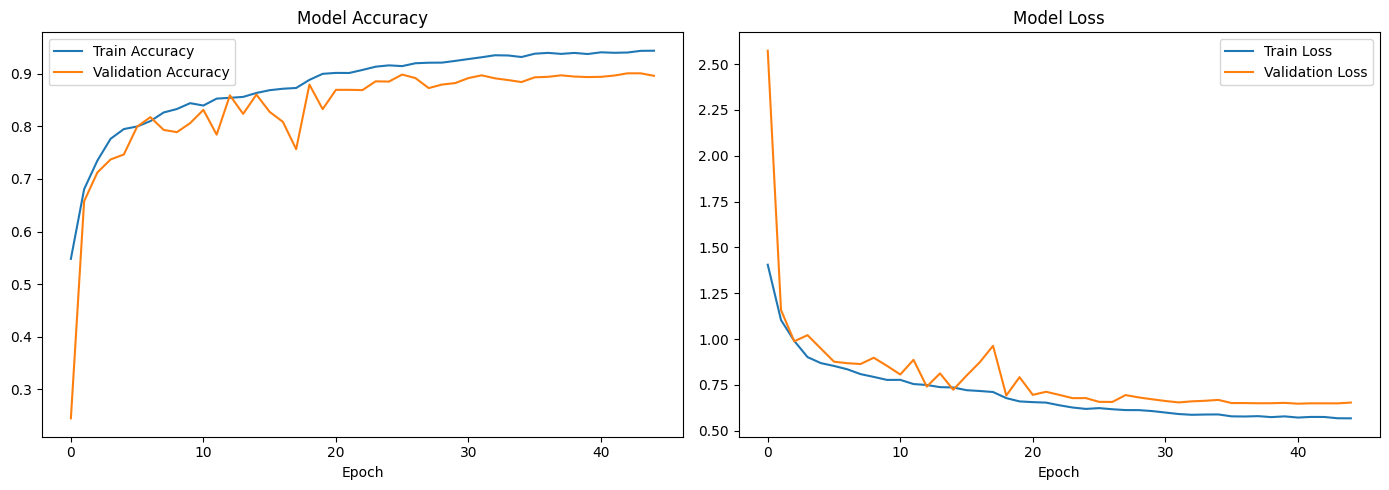

In [14]:
# plot accuracy and loss curves for the best model (train vs validation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(best_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(best_history.history['loss'], label='Train Loss')
axes[1].plot(best_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout(); plt.show()

Found 3000 images belonging to 6 classes.
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step


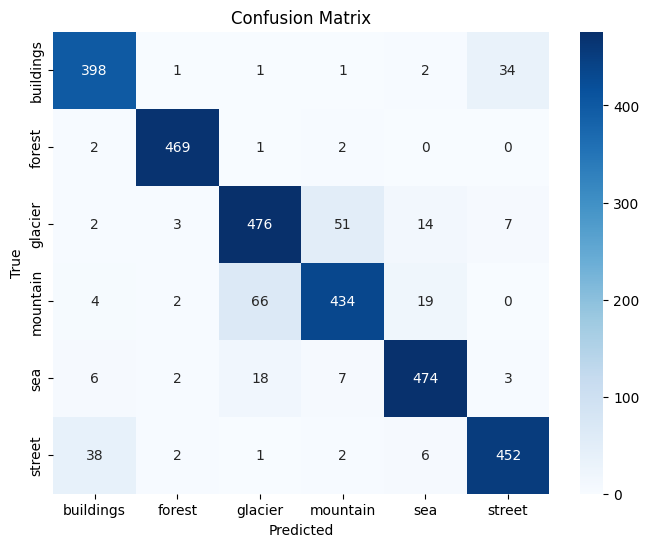

              precision    recall  f1-score   support

   buildings       0.88      0.91      0.90       437
      forest       0.98      0.99      0.98       474
     glacier       0.85      0.86      0.85       553
    mountain       0.87      0.83      0.85       525
         sea       0.92      0.93      0.92       510
      street       0.91      0.90      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# fresh test generator to avoid mismatched predictions/labels
test_gen_final = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

# get predictions from the best model
y_pred_probs = best_model.predict(test_gen_final, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen_final.classes

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# precision, recall, F1-score per class
print(classification_report(y_true, y_pred, target_names=class_names))